# InSAR Workflow Input Selection

## ESA ClouDInSAR

**Authors:**  
_Mattia Callegari, Eurac Research_  
_Michele Claus, Eurac Research_

**Release Date:**  
May 06, 2025

## Objectives:
- Learn how to interact with the CDSE burst catalog, performing a query based on your temporal and spatial range of interest.

- Understand why accessing single bursts can optimize your workflow.

- Filter the desired products based on track and polarization.

- Get the perpendicular and temporal baseline of the selected product pairs and select only the required for our analysis.

- Finally, define the input parameters required by the openEO workflow: polarization, burst Id, subswath, InSAR pairs list.

## Setup

Open the python notebook in CDSE JupyterLab and select the `esa-snap` kernel. Then install some additional needed libraries:

In [1]:
pip install shapely folium leafmap

Note: you may need to restart the kernel to use updated packages.


In [1]:
import urllib.request
url = "https://raw.githubusercontent.com/cloudinsar/s1-workflows/refs/heads/restructure_examples/examples/s1_burst_lib.py"
file_Path = "/home/jovyan/s1_burst_lib.py"
urllib.request.urlretrieve(url, file_Path)

('/home/jovyan/s1_burst_lib.py', <http.client.HTTPMessage at 0x7f3a95618440>)

## Import the `s1_burst_lib` python module

In [2]:
from s1_burst_lib import *

Error while parsing JAI registry file "file:/opt/conda/envs/snap/esa-snap/snap/modules/ext/org.esa.snap.snap-core/org-geotools/gt-coverage.jar!/META-INF/registryFile.jai" :
Error in registry file at line number #31
A descriptor is already registered against the name "org.geotools.ColorReduction" under registry mode "rendered"
Error in registry file at line number #32
A descriptor is already registered against the name "org.geotools.ColorInversion" under registry mode "rendered"
Error while parsing JAI registry file "file:/opt/conda/envs/snap/esa-snap/snap/modules/ext/org.esa.snap.snap-core/org-jaitools/jt-zonalstats.jar!/META-INF/registryFile.jai" :
Error in registry file at line number #4
A descriptor is already registered against the name "ZonalStats" under registry mode "rendered"
Error while parsing JAI registry file "file:/opt/conda/envs/snap/esa-snap/snap/modules/ext/org.esa.snap.snap-gpf/org-jaitools/jt-vectorize.jar!/META-INF/registryFile.jai" :
Error in registry file at line n

## Input definition

Select polarization and the temporal range of interest defining the start and end dates

In [3]:
pol = "VV"
start_date = "2024-01-01"
end_date = "2025-01-30"

Define an area of interest by drawing in the map using the rectangle selection tool

In [13]:
m = leafmap.Map(center=(47.005, 11.507), zoom=7.5)
m

Map(center=[47.005, 11.507], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom…

In [14]:
feat = m.draw_features
geom_dict = feat[0]['geometry']
geom = shape(geom_dict)
aoi = geom.wkt
# Or provide it manually:
# aoi = "POLYGON ((11.28 46.47, 11.28 46.52, 11.44 46.52, 11.44 46.47, 11.28 46.47))" # e.g. 'POLYGON ((11.28 46.47, 11.28 46.52, 11.44 46.52, 11.44 46.47, 11.28 46.47))'

## 2. CDSE Bursts Catalog Query

Retrieve the bursts info with an https request to the CDSE OData API.

In [15]:
s1_bursts = retrieve_bursts(start_date, end_date, pol, aoi)

## Show On Map

Show the Sentinel-1 bursts on a map.

In [16]:
tracks, m = show_bursts(s1_bursts, aoi)
m

## Plot Acquisition Calendar

To understand the result of our data query for Sentinel-1, we plot here a visual calendar showing on which date the corresponding track has been acquired.

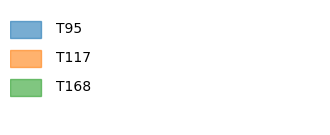

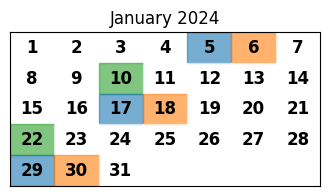

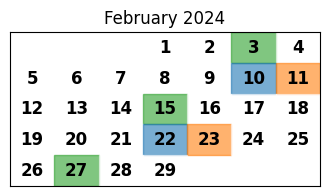

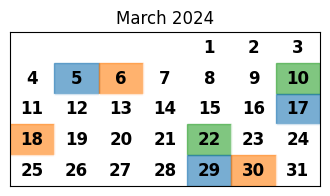

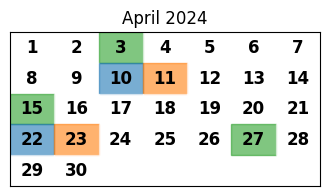

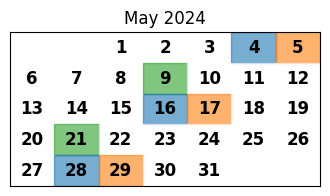

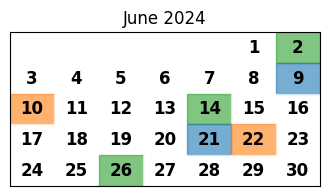

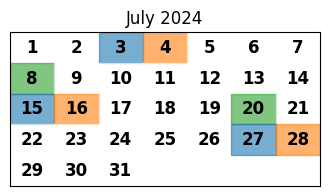

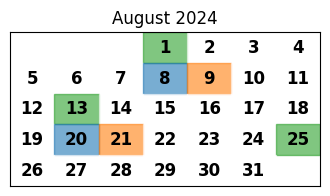

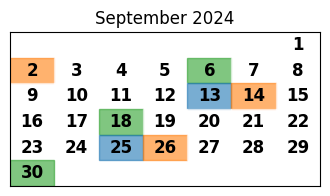

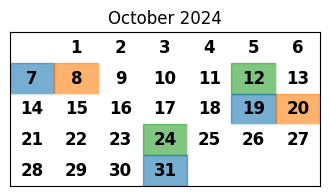

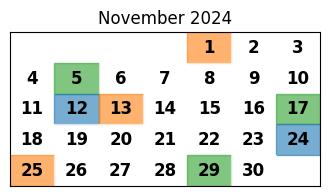

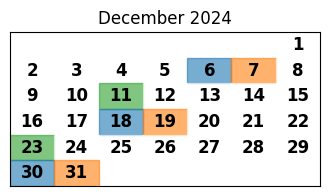

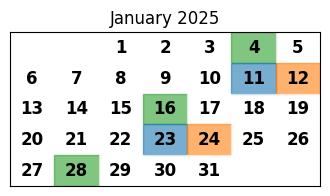

In [17]:
show_acquisition_calendar(s1_bursts)

## Filter with Track, Burst ID and Polarization

Now we can select the necessary parameters we will need in our openEO workflow.  
Select one of the available sub_swath_identifier (i.e. iw1, iw2, iw3) and burstId from the following list or from the map widget above.

In [18]:
for x in tracks:
  print(x["label"])
  for y in x["children"]:
    print("  " + y["label"]) 

Track 95
  BurstId: 202703, IW3
  BurstId: 202704, IW3
Track 168
  BurstId: 359501, IW1
  BurstId: 359502, IW1
Track 117
  BurstId: 249433, IW2
  BurstId: 249434, IW2


Set the required polarization, subswath identifier and correspondant burst id.  
Currently we have to select only a single burst due to a limitation of the current implementation.

In [19]:
sub_swath_identifier = "iw2"
burst_id = "249434"
polarization = "VV"

## Download Sentinel-1 metadata

Get the metadata from the S3 bucket. You need to insert your [CDSE S3 credentials](https://eodata-s3keysmanager.dataspace.copernicus.eu/panel/s3-credentials).  
The code in the next cell will download only the necessary metadata files required to compute the perpendicular baseline using the ESA SNAP toolbox.  
It will also create empty geotiff images and replicate the folder structure of a full Sentinel-1 product stored with the SAFE format. This will allow us to use SNAP for this task.

In [ ]:
CDSE_ACCESS_KEY = ""
CDSE_SECRET_KEY = ""

s1_fileList = download_s1metadata(s1_bursts, sub_swath_identifier, burst_id, CDSE_ACCESS_KEY, CDSE_SECRET_KEY)
s1_fileList

['S1A_IW_SLC__1SDV_20240223T170721_20240223T170748_052689_065FFC_3817.SAFE',
 'S1A_IW_SLC__1SDV_20240130T170721_20240130T170748_052339_065425_776A.SAFE',
 'S1A_IW_SLC__1SDV_20240318T170721_20240318T170748_053039_066C27_017D.SAFE',
 'S1A_IW_SLC__1SDV_20240306T170721_20240306T170748_052864_0665F0_9D32.SAFE',
 'S1A_IW_SLC__1SDV_20240211T170721_20240211T170748_052514_065A09_E4A5.SAFE',
 'S1A_IW_SLC__1SDV_20240330T170722_20240330T170749_053214_0672CD_0A27.SAFE',
 'S1A_IW_SLC__1SDV_20240106T170722_20240106T170749_051989_064848_8293.SAFE',
 'S1A_IW_SLC__1SDV_20240118T170721_20240118T170748_052164_064E38_D3B2.SAFE',
 'S1A_IW_SLC__1SDV_20240529T170722_20240529T170749_054089_0693B0_613D.SAFE',
 'S1A_IW_SLC__1SDV_20240622T170721_20240622T170748_054439_069FC6_BC60.SAFE',
 'S1A_IW_SLC__1SDV_20240505T170722_20240505T170749_053739_068777_4560.SAFE',
 'S1A_IW_SLC__1SDV_20240610T170721_20240610T170748_054264_0699BB_8D56.SAFE',
 'S1A_IW_SLC__1SDV_20240411T170721_20240411T170747_053389_0679AE_5A2F.SAFE',

### InSAR pair list for SBAS (Small Baseline Subset) configuration

112245 [main] INFO hdf.hdflib.HDFLibrary - HDF4 library: 
112245 [main] INFO hdf.hdflib.HDFLibrary -  successfully loaded.
112249 [main] INFO hdf.hdf5lib.H5 - HDF5 library: 
112249 [main] INFO hdf.hdf5lib.H5 -  successfully loaded.
SEVERE: org.esa.snap.core.dataio.ProductIO: Error attempting to read S1A_IW_SLC__1SDV_20240223T170721_20240223T170748_052689_065FFC_3817.SAFE with plugin reader org.csa.rstb.io.rcm.RCMProductReaderPlugIn@3f9b7fe1
java.lang.NullPointerException: Cannot invoke "java.io.File.getName()" because the return value of "java.io.File.getParentFile()" is null
	at org.csa.rstb.io.rcm.RCMProductReaderPlugIn.findMetadataFile(RCMProductReaderPlugIn.java:67)
	at org.csa.rstb.io.rcm.RCMProductReaderPlugIn.getDecodeQualification(RCMProductReaderPlugIn.java:57)
	at org.esa.snap.core.dataio.ProductIO.getProductReaderForInput(ProductIO.java:288)
	at org.esa.snap.core.dataio.ProductIO.readProductImpl(ProductIO.java:253)
	at org.esa.snap.core.dataio.ProductIO.readProduct(ProductIO

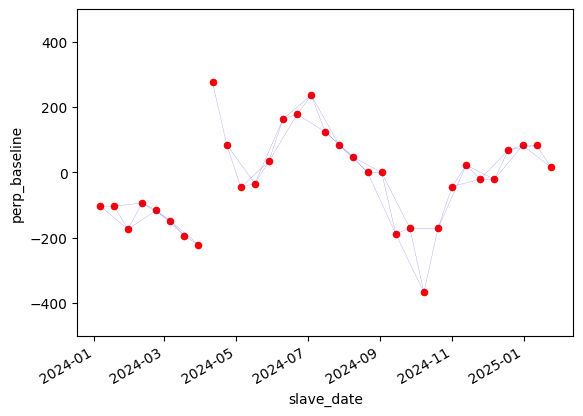

In [21]:
sbas_pairs_list = sbas_pairs(s1_fileList, max_temporal_baseline=24, max_perp_baseline=200)

### InSAR pair list for PS (Persistent Scatterer) configuration

SEVERE: org.esa.snap.core.dataio.ProductIO: Error attempting to read S1A_IW_SLC__1SDV_20240223T170721_20240223T170748_052689_065FFC_3817.SAFE with plugin reader org.csa.rstb.io.rcm.RCMProductReaderPlugIn@3f9b7fe1
java.lang.NullPointerException: Cannot invoke "java.io.File.getName()" because the return value of "java.io.File.getParentFile()" is null
	at org.csa.rstb.io.rcm.RCMProductReaderPlugIn.findMetadataFile(RCMProductReaderPlugIn.java:67)
	at org.csa.rstb.io.rcm.RCMProductReaderPlugIn.getDecodeQualification(RCMProductReaderPlugIn.java:57)
	at org.esa.snap.core.dataio.ProductIO.getProductReaderForInput(ProductIO.java:288)
	at org.esa.snap.core.dataio.ProductIO.readProductImpl(ProductIO.java:253)
	at org.esa.snap.core.dataio.ProductIO.readProduct(ProductIO.java:205)

SEVERE: org.esa.snap.core.dataio.ProductIO: Error attempting to read S1A_IW_SLC__1SDV_20240130T170721_20240130T170748_052339_065425_776A.SAFE with plugin reader org.csa.rstb.io.rcm.RCMProductReaderPlugIn@3f9b7fe1
java.la

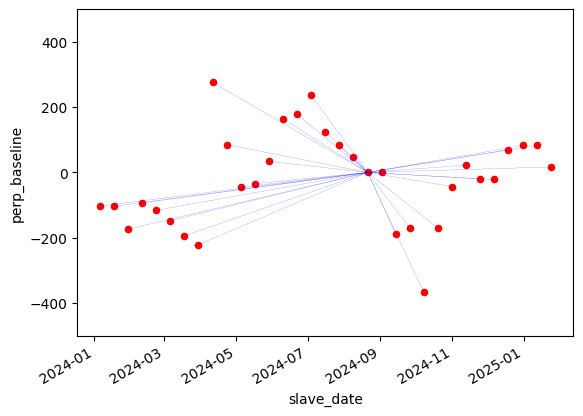

In [22]:
ps_pairs_list = ps_pairs(s1_fileList)

## Recap

In this notebook we were able to interact with CDSE and its API to define the necessary parameters for the Sentinel-1 InSAR workflow we will run with openEO.

The selected parameters are:

In [24]:
print(f"Selected polarization: {polarization}")
print(f"Selected subswath: {sub_swath_identifier}")
print(f"Selected burst id: {burst_id}")
print(f"Selected InSAR date pairs for SBAS:")
print(*sbas_pairs_list,sep='\n')
print(f"\nSelected InSAR date pairs for PS:")
print(*ps_pairs_list,sep='\n')

Selected polarization: VV
Selected subswath: iw2
Selected burst id: 249434
Selected InSAR date pairs for SBAS:
['2024-02-23', '2024-03-18']
['2024-02-23', '2024-03-06']
['2024-01-30', '2024-02-23']
['2024-01-30', '2024-02-11']
['2024-03-18', '2024-03-30']
['2024-03-06', '2024-03-18']
['2024-03-06', '2024-03-30']
['2024-02-11', '2024-02-23']
['2024-02-11', '2024-03-06']
['2024-01-06', '2024-01-30']
['2024-01-06', '2024-01-18']
['2024-01-18', '2024-01-30']
['2024-01-18', '2024-02-11']
['2024-05-29', '2024-06-22']
['2024-05-29', '2024-06-10']
['2024-06-22', '2024-07-04']
['2024-06-22', '2024-07-16']
['2024-05-05', '2024-05-29']
['2024-05-05', '2024-05-17']
['2024-06-10', '2024-06-22']
['2024-06-10', '2024-07-04']
['2024-04-11', '2024-04-23']
['2024-04-23', '2024-05-05']
['2024-04-23', '2024-05-17']
['2024-05-17', '2024-05-29']
['2024-05-17', '2024-06-10']
['2024-09-26', '2024-10-08']
['2024-09-26', '2024-10-20']
['2024-08-21', '2024-09-02']
['2024-08-21', '2024-09-14']
['2024-09-02', '202